# Lista 4 - KONWOLUCJE

In [2]:
import numpy as np
import torch
from scipy.signal import convolve2d
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchinfo import summary
from numpy.lib.stride_tricks import sliding_window_view

## Zad1:

### Na początek stwórzmy funkcję, do przeprowadzania konwolucji  filtrem K na obrazie X:
Zamiast robić konwolucje pętlą, możemy wykorzystać operacje na macierzach, aby zoptymalizować działanie kodu. Dodatkowo wprowadzimy do funkcji możliwość ustawienia paddingu. Stride sztywno ustawiamy na 1

In [3]:
def convolution(X, K, q: int, padding: int = 0):
  '''
  Wykonuje operację konwolucji na wejściowym obrazie *X* oraz filtrze *K*. 
  Args:
    X: numpy / torch tensor o wymiarach (h, w, d)
    K: numpy / torch tensor o wymiarach (k_h, k_w, d, q)
    q: liczba filtrów
    padding: liczba pikseli paddingu dodawanych wokół obrazu (domyślnie 0)
  '''
  
  # Uwzględnimy oba przypadki - numpy i torch
  is_torch = isinstance(X, torch.Tensor)
  
  if padding > 0:
    if is_torch:
      X = F.pad(X.permute(2, 0, 1), (padding, padding, padding, padding), mode='constant', value=0).permute(1, 2, 0)
    else:
      X = np.pad(X, ((padding, padding), (padding, padding), (0, 0)), mode='constant', constant_values=0)
  
  h, w, d = X.shape
  k_h, k_w, _, _ = K.shape  

  # stride = 1
  h_out = h - k_h + 1
  w_out = w - k_w + 1
  
  if is_torch:
    # Przekształcamy X z (h, w, d) na (d, h, w) na potrzeby funkcji unfold
    X_permuted = X.permute(2, 0, 1).unsqueeze(0)  # (1, d, h, w)
    
    # patches ma kształt (1, d*k_h*k_w, h_out*w_out)
    patches = F.unfold(X_permuted, kernel_size=(k_h, k_w), stride=1)
    
    # Przekształcamy: (1, d*k_h*k_w, h_out*w_out) -> (d*k_h*k_w, h_out*w_out)
    patches = patches.squeeze(0) 
    
    # Zmieniamy kolejność, aby dostać (h_out*w_out, k_h*k_w*d)
    patches = patches.reshape(d, k_h * k_w, -1)  # (d, k_h*k_w, h_out*w_out)
    patches = patches.permute(2, 1, 0)  # (h_out*w_out, k_h*k_w, d)
    patches = patches.reshape(-1, k_h * k_w * d)  # (h_out*w_out, k_h*k_w*d)
    
    # Reshape filtra K z (k_h, k_w, d, q) na (k_h*k_w*d, q)
    K_reshaped = K.reshape(-1, q)
    
    # Mnożenie macierzowe
    output = torch.matmul(patches, K_reshaped)
    
    # Reshape do (h_out, w_out, q)
    output = output.reshape(h_out, w_out, q)
    
  else:
    # NumPy - używamy sliding_window_view
    patches = sliding_window_view(X, (k_h, k_w, d))
    
    # Reshape do (h_out, w_out, k_h*k_w*d)
    patches = patches.reshape(h_out, w_out, -1)
    
    # Reshape filtra K z (k_h, k_w, d, q) na (k_h*k_w*d, q)
    K_reshaped = K.reshape(-1, q)
    
    # Mnożenie macierzowe
    output = np.dot(patches, K_reshaped)
  
  return output

### Przypadki testowe

In [4]:
def generate_deterministic_tensor(shape, mod_val=5, offset=0):
    count = 1
    for s in shape:
        count *= s
    # Tworzymy sekwencję 0, 1, 2... i bierzemy modulo
    data = torch.arange(count).float() % mod_val + offset
    return data.reshape(shape)

def torch_2_numpy(pt):
  return pt.detach().numpy()

def run_pytorch_test(case_name, img_hwc, kernel_hwcn):
    image_hwc = generate_deterministic_tensor(img_hwc, mod_val=5)
    kernel_hwcn = generate_deterministic_tensor(kernel_hwcn, mod_val=3, offset=-1)

    print(f"Input shape (H,W,C): {tuple(image_hwc.shape)}")
    print(f"Kernel shape (H,W,Cin,Cout): {tuple(kernel_hwcn.shape)}")

    # Dodanie wymiaru batcha
    input_tensor = image_hwc.permute(2, 0, 1).unsqueeze(0)
    weights = kernel_hwcn.permute(3, 2, 0, 1)
    output_tensor = F.conv2d(input_tensor, weights, stride=1, padding=0)
    output_hwc = output_tensor.squeeze(0).permute(1, 2, 0)

    # ODKOMENTUJ JEŚLI twoim inputem jest wielowymiarowa macierz NumPy
    # image_hwc = torch_2_numpy(image_hwc)
    # kernel_hwcn = torch_2_numpy(kernel_hwcn)

    my_output = convolution(image_hwc, kernel_hwcn, kernel_hwcn.shape[-1])
    if isinstance(my_output, np.ndarray):
        my_output = torch.from_numpy(my_output)

    my_output = my_output.to(torch.float64)
    output_hwc = output_hwc.to(torch.float64) # do samego typu żeby nie było błędu

    try:
      torch.testing.assert_close(my_output, output_hwc, rtol=1e-05, atol=1e-08)
      print(f"Test zaliczony")
    except AssertionError as e:
      print(f"Test niezaliczony: {e}")
    print(f"Output shape (H,W,C): {tuple(output_hwc.shape)}")

# --- URUCHOMIENIE PRZYPADKÓW ---

# Przypadek 1: Mały
run_pytorch_test("PRZYPADEK 1", (6, 6, 3), (3, 3, 3, 5))

# Przypadek 2: Średni
run_pytorch_test("PRZYPADEK 2", (12, 12, 3), (3, 3, 3, 5))

# Przypadek 3: Projekcja 1x1
run_pytorch_test("PRZYPADEK 3", (24, 24, 3), (1, 1, 3, 10))

Input shape (H,W,C): (6, 6, 3)
Kernel shape (H,W,Cin,Cout): (3, 3, 3, 5)
Test zaliczony
Output shape (H,W,C): (4, 4, 5)
Input shape (H,W,C): (12, 12, 3)
Kernel shape (H,W,Cin,Cout): (3, 3, 3, 5)
Test zaliczony
Output shape (H,W,C): (10, 10, 5)
Input shape (H,W,C): (24, 24, 3)
Kernel shape (H,W,Cin,Cout): (1, 1, 3, 10)
Test zaliczony
Output shape (H,W,C): (24, 24, 10)


Wszystko  śmiga

## Zad 2:

funkcja do sprawdzania:

In [5]:
def validate_layer(case_name, layer, input_shape, expected_shape):
    print(f"--- {case_name} ---")
    print(f"Input: {input_shape}")

    # Tworzymy losowy tensor z batch=1
    x = torch.randn(1, *input_shape)

    try:
        y = layer(x)
        out_shape = tuple(y.shape)[1:] # bez batch

        print(f"Oczekiwany kształt: {expected_shape}")
        print(f"Twój kształt:       {out_shape}")

        if out_shape == expected_shape:
            print("OK. \n")
        else:
            print("Błąd: Kształty się nie zgadzają.\n")

    except Exception as e:
        print(f"Jakiś błąd: {e}\n")

PRZYPADEK 1: Agresywna redukcja (styl pierwszej warstwy AlexNet)

Wejście: 224x224 (obraz)

Wyjście: 55x55

Wymagane: Użyj Padding=2. Resztę dobierz.

Wskazówka: Kernel jest duży (>7), a krok (stride) też jest spory (>2).

In [6]:
case_1 = nn.Conv2d(
    in_channels=3,
    out_channels=64,
    padding=2,
    dilation=1,
    # --- DO UZUPEŁNIENIA ---
    kernel_size=1,  # <-- zmień to
    stride=1        # <-- zmień to
)


No to tutaj musimy podłożyć do wzoru na W out:
$$55 = \left\lfloor \frac{224 + 2(2) - 1*(K-1)-1}{S} \right\rfloor + 1$$
Z czego otrzymujemy:
$$ K = 224 + 2*2 - S(55-1)  => K = 228 - 54S  $$

Teraz wystarczy podstawić jaką wartośc w miejsce K lub S i drugie się łatwo wyliczy.
Do takich par należą chociażby $$ K = 174 , S = 1$$ lub $$K = 66 , S = 3$$ No tu widzimy że im mniejszy stride, tym większy jest kernel a używanie tak dużego filtra nie wydaje się rozsądne, ale para$$ K = 12 , S = 4$$  już sens w miarę ma. 

In [7]:
case_1 = nn.Conv2d(
    in_channels=3,
    out_channels=64,
    padding=2,
    dilation=1,
    kernel_size=12,  
    stride=4       
)

Test 1

In [8]:

validate_layer("PRZYPADEK 1: Redukcja 224 -> 55", case_1,
                input_shape=(3, 224, 224),
                expected_shape=(64, 55, 55))

--- PRZYPADEK 1: Redukcja 224 -> 55 ---
Input: (3, 224, 224)
Oczekiwany kształt: (64, 55, 55)
Twój kształt:       (64, 55, 55)
OK. 



PRZYPADEK 2: Asymetryczna konwolucja

Wejście: 32x32

Wyjście: 30x16

Wymagane: Padding=0.

Wskazówka: Wysokość (32->30) maleje wolno, Szerokość (32->16) maleje szybko.

Użyj krotki (tuple) dla kernel_size i stride, np. (h, w).

In [9]:
case_2 = nn.Conv2d(
    in_channels=1,
    out_channels=1,
    padding=0,
    dilation=1,
    # --- DO UZUPEŁNIENIA ---
    kernel_size=(1, 1), # <-- zmień to
    stride=(1, 1)       # <-- zmień to
)


Korzystając z tego samego wzoru, musimy obliczyć osobno wartości dla wysokości i osobno dla szerokości:
1. wysokość
$$30 = \lfloor \frac{32 +2*0 - 1*(K_h-1)-1}{S_h} \rfloor + 1 <=> 30 = \lfloor \frac{32 - K_h}{S_h} \rfloor + 1$$
tutaj zmiana wartości nie jest ogromna, więc jeżeli przyjmiemy $S_h = 1$, to $K_h$ nam wyjdzie 3 i to jest okej

2. szerokość

Tutaj różnica w wartościach jest większa i sytuacja ma się podobnie co w pierwszym zadaniu
$$ K_w = 32 - 15S_w$$
i tak jak zadanie wyżej, $S_w = 1$ da nam dosyć spory filtr, więc wolę użyć
$$ K_w = S_w = 2$$

In [10]:
case_2 = nn.Conv2d(
    in_channels=1,
    out_channels=1,
    padding=0,
    dilation=1,
    kernel_size=(3, 2), 
    stride=(1, 2)       
)

Test 2

In [11]:
validate_layer("PRZYPADEK 2: Prostokątne okna 32 -> 30x16", case_2,
                input_shape=(1, 32, 32),
                expected_shape=(1, 30, 16))

--- PRZYPADEK 2: Prostokątne okna 32 -> 30x16 ---
Input: (1, 32, 32)
Oczekiwany kształt: (1, 30, 16)
Twój kształt:       (1, 30, 16)
OK. 



PRZYPADEK 3: "Dziurawy" Kernel (Dilated Convolution)

Wejście: 50x50

Wyjście: 46x46

Wymagane: Stride=1, Padding=0. Kernel ma rozmiar 3x3.

Zastanów się jak to możliwe, że kernel (3, 3) zmniejsza wielkość aż o 4 piksele?

In [12]:
case_3 = nn.Conv2d(
    in_channels=16,
    out_channels=16,
    stride=1,
    padding=0,
    kernel_size=3,
    # --- DO UZUPEŁNIENIA ---
    dilation=1  # <-- zmień to
)

No to ten sam wzór, ale jedyną zmienną jest dylatacja:
$$ 46 = \lfloor \frac{50 + 2*0 - D*(3-1)-1}{1} \rfloor + 1 <=> 46 = 50 - 2D - 1 + 1$$
A więc:
$$ D = 2

In [13]:
case_3 = nn.Conv2d(
    in_channels=16,
    out_channels=16,
    stride=1,
    padding=0,
    kernel_size=3,
    dilation=2
)

Test 3

In [14]:
validate_layer("PRZYPADEK 3: Dylatacja 50 -> 46", case_3,
                input_shape=(16, 50, 50),
                expected_shape=(16, 46, 46))

--- PRZYPADEK 3: Dylatacja 50 -> 46 ---
Input: (16, 50, 50)
Oczekiwany kształt: (16, 46, 46)
Twój kształt:       (16, 46, 46)
OK. 



Przez to, że dylatacja jest ustawiona na 2, a nie na 1 to 3x3 filtr, wyciąga wartości z obszaru 5x5, ponieważ pomiędzy każdą wartością odczytywaną, jest jedna wartość pomijana

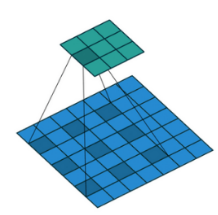

I teraz jeżeli przeszukujemy obszar 5x5 wokół piksela X, to znaczy, że filtr bierze pod uwagę obszar 2 pikseli wokół piksela X, więc dla pikseli granicznych, z racji że nie ma paddingu ucinamy po 2 piksele z każdej strony, lewo prawo góra dół i takim oto sposobem mamy rozmiar 46x46

## Zad 3

pobieramy dataset, będziemy pracować nad zbiorem CIFAR10

In [18]:
from torchvision import datasets

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)) 
  ])

trainset = datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

testset = datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

 Podstawowe informacje o zbiorze CIFAR-10

In [23]:
# Liczba przykładów
print(f"\n Rozmiar zbiorów:")
print(f"   Zbiór treningowy:  {len(trainset):,} obrazów")
print(f"   Zbiór testowy:     {len(testset):,} obrazów")
print(f"   Razem:             {len(trainset) + len(testset):,} obrazów")

# Kształt danych
sample_image, sample_label = trainset[0]
print(f"\n  Wymiary obrazów:")
print(f"   Kształt tensora:   {tuple(sample_image.shape)} (C, H, W)")


# Klasy
classes = trainset.classes
print(f"\n  Klasy ({len(classes)} kategorii):")
for i, class_name in enumerate(classes):
    print(f"   {i}: {class_name}")

# Rozkład klas w zbiorze treningowym 
print(f"\n Liczba zdjęć w każdej klasie :")
class_counts = {}
for _, label in trainset:
    class_name = classes[label]
    class_counts[class_name] = class_counts.get(class_name, 0) + 1

for class_name in classes:
    count = class_counts.get(class_name, 0)
    print(f"   {class_name:12s}: {count:,} zdjęć")

print(f"\n   RAZEM: {sum(class_counts.values()):,} zdjęć")



 Rozmiar zbiorów:
   Zbiór treningowy:  50,000 obrazów
   Zbiór testowy:     10,000 obrazów
   Razem:             60,000 obrazów

  Wymiary obrazów:
   Kształt tensora:   (3, 32, 32) (C, H, W)

  Klasy (10 kategorii):
   0: airplane
   1: automobile
   2: bird
   3: cat
   4: deer
   5: dog
   6: frog
   7: horse
   8: ship
   9: truck

 Liczba zdjęć w każdej klasie :
   airplane    : 5,000 zdjęć
   automobile  : 5,000 zdjęć
   bird        : 5,000 zdjęć
   cat         : 5,000 zdjęć
   deer        : 5,000 zdjęć
   dog         : 5,000 zdjęć
   frog        : 5,000 zdjęć
   horse       : 5,000 zdjęć
   ship        : 5,000 zdjęć
   truck       : 5,000 zdjęć

   RAZEM: 50,000 zdjęć
